In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DIR = "/Users/mandakausthubh/ML_Research/StatML/Statistical-Machine-Learning-AIM-102-2026/Week1"

In [3]:
# Creating the original Function f^*(x)
"""
This is the true function that is observed in (supposed to be) nature!! (We are just simulating it!!)
"""
true_params = np.array([3,5], dtype=np.float16)

def f(x): return np.matmul(true_params, x)

In [4]:
# Our Observations

# Defining our parameters for a normal distribution
mean = 5
variance = 3.5
sample_size = 100

x_vals = np.random.normal(mean, variance, sample_size)
x_vals = np.vstack((x_vals, np.ones_like(x_vals)))
x_vals.shape

(2, 100)

(array([2., 0., 0., 0., 0., 0., 1., 0., 2., 0., 0., 0., 1., 2., 1., 2., 1.,
        2., 2., 4., 5., 5., 3., 2., 6., 3., 3., 1., 1., 5., 4., 4., 4., 3.,
        5., 5., 0., 4., 4., 4., 2., 1., 1., 0., 1., 1., 0., 2., 0., 1.]),
 array([-5.47149056, -5.07626816, -4.68104577, -4.28582338, -3.89060098,
        -3.49537859, -3.10015619, -2.7049338 , -2.3097114 , -1.91448901,
        -1.51926662, -1.12404422, -0.72882183, -0.33359943,  0.06162296,
         0.45684536,  0.85206775,  1.24729015,  1.64251254,  2.03773493,
         2.43295733,  2.82817972,  3.22340212,  3.61862451,  4.01384691,
         4.4090693 ,  4.8042917 ,  5.19951409,  5.59473648,  5.98995888,
         6.38518127,  6.78040367,  7.17562606,  7.57084846,  7.96607085,
         8.36129325,  8.75651564,  9.15173803,  9.54696043,  9.94218282,
        10.33740522, 10.73262761, 11.12785001, 11.5230724 , 11.9182948 ,
        12.31351719, 12.70873958, 13.10396198, 13.49918437, 13.89440677,
        14.28962916]),
 <BarContainer object

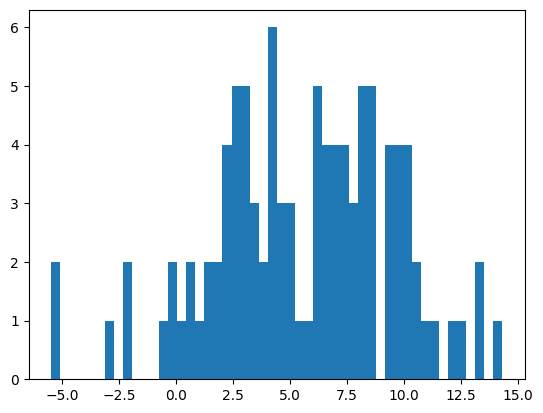

In [5]:
plt.hist(x_vals[0, :], bins=50)

In [6]:
# Our Y-observations: f(x) + some noise

# Noise configuration
noise_mean = 0  # Why not otherwise??
noise_std = 3

y_vals = f(x_vals) + np.random.normal(0, noise_std, sample_size)

In [7]:
y_vals.shape, x_vals.shape

((100,), (2, 100))

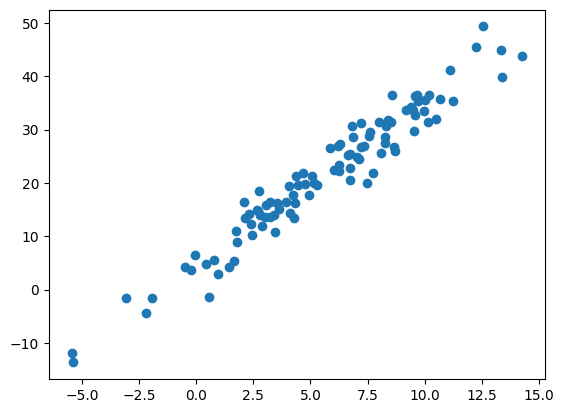

In [8]:
plt.scatter(x_vals[0, :], y_vals)

In [9]:
# This is now where our algorithm and model come in!!

"""
The point of *Supervised Learning* is that, given this data, can we faithfully reconstruct our original dataset?

Step-1: Guess what the original type function was?? (Hypothesis Set: Let's try linear!!)
Step-2: Define what Good or Bad is?? (Loss function!!)
Step-3: Now, from the hypothesis set, can we find the best function that fits this?? (Learning Algorithm!!)
"""

# Step-1: Hypothesis Set: Linear
model_params = np.random.rand(2)
# model_params = np.array([2, -10], dtype=np.float16)
def hypothesis(x): return np.matmul(model_params, x)

model_params

array([0.1916704 , 0.19139302])

In [10]:
# Step-2: Loss function: MSE (Mean Squared Error)
def MSE(y_true, y_pred): return np.sum((y_true - y_pred)**2)

pred_initial = hypothesis(x_vals)
MSE(y_vals, pred_initial)

np.float64(54299.640239096385)

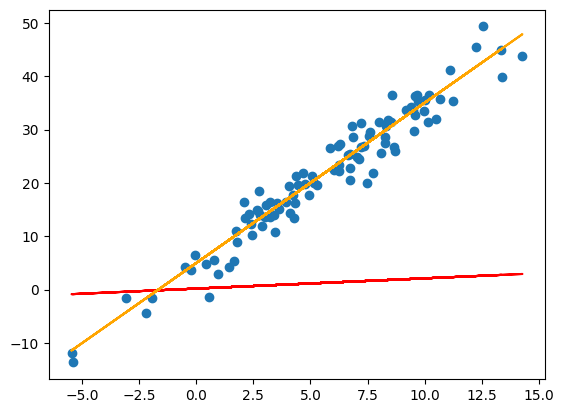

In [11]:
plt.plot(x_vals[0, :], hypothesis(x_vals), color='r')
plt.plot(x_vals[0, :], f(x_vals), color='orange')
plt.scatter(x_vals[0, :], y_vals)

In [12]:
x_vals.shape, y_vals.shape, hypothesis(x_vals).shape, model_params.shape

((2, 100), (100,), (100,), (2,))

In [13]:
import os

os.makedirs(os.path.join(DIR, "frames"), exist_ok=True)

In [14]:
def grad():
    errors = hypothesis(x_vals) - y_vals   # shape (N,)
    return (2 / len(y_vals)) * x_vals @ errors

learning_rate=1e-5

n_iter = 5000

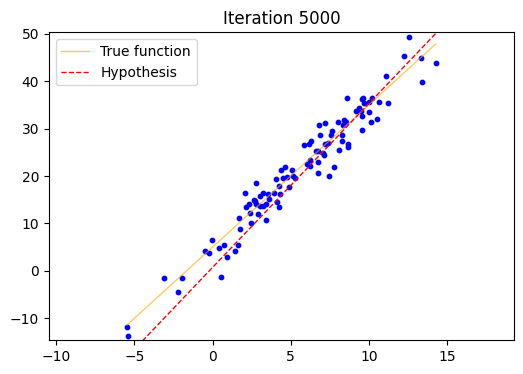

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x_vals[0, :], y_vals, color="blue", s=10)

x_line = np.linspace(min(x_vals[0, :]), max(x_vals[0, :]), 100)
x_line_stacked = np.vstack((x_line, np.ones_like(x_line)))

ax.plot(
    x_line, f(x_line_stacked),
    color="orange", lw=1, alpha=0.6, label="True function"
)

hyp_line, = ax.plot(
    x_line, hypothesis(x_line_stacked),
    color="red", lw=1, linestyle="--", label="Hypothesis"
)

ax.legend()
ax.set_xlim(min(x_vals[0, :]) - 5, max(x_vals[0, :]) + 5)
ax.set_ylim(min(y_vals) - 1, max(y_vals) + 1)

frame_id = 0
MSE_vals = []


for i in range(n_iter):

    # SGD update FIRST
    model_params -= learning_rate * grad()

    # Update plot
    hyp_line.set_ydata(hypothesis(x_line_stacked))
    ax.set_title(f"Iteration {i+1}")

    # Save frame
    if i % 5 == 0:
        plt.savefig(
            os.path.join(DIR, f"frames/frame_{frame_id:04d}.png"),
            # bbox_inches="tight"
        )
        frame_id += 1

    MSE_vals.append(MSE(y_vals, hypothesis(x_vals)))


In [16]:
!pwd

/Users/mandakausthubh/ML_Research/StatML/Statistical-Machine-Learning-AIM-102-2026/Week1


In [17]:
!ffmpeg -framerate 10 -i ./frames/frame_%04d.png sgd.gif

ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.4.4.1)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --

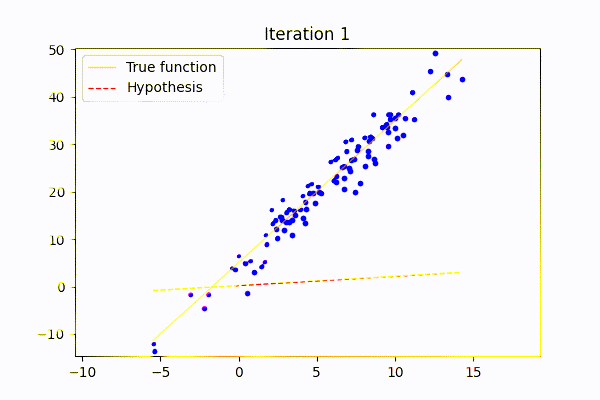

In [18]:
from IPython.display import Image, display

display(Image(filename=os.path.join(DIR, "sgd.gif")))

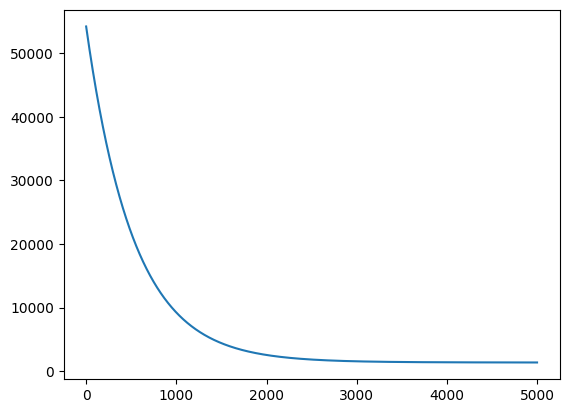

In [19]:
plt.plot(MSE_vals)